In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Sequence, Union
import operator
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\tcpad\AppData\Local\Temp\ipykernel_31284\1321183317.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [3]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    

In [4]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

        print(f"Soy el init del agente, tengo {len(tools)} herramientas y el sistema es: {system}")
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamado a la herramienta: {t}")
            if t['name'] not in self.tools:
                print("\n ...Nombre de herramienta desconocido...")
                result = "Nombre de herramienta desconocido, intente de nuevo"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Volviendo al modelo!")
        return {'messages': results}

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        print("Llamando a Gemini desde call_gemini...")
        messages = state['messages']
        print(f"Mensajes recibidos en call_gemini: {messages}")
        if self.system: 
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

In [5]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

In [6]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""
Eres un asistente de investigación inteligente y altamente actualizado. \
Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. \
La fecha actual es {{current_date}}. \
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", \
DEBES **incluir la fecha actual `{current_date}` en tu consulta para la herramienta de búsqueda**. \
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". \
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". \
Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. \
Tienes permiso para realizar múltiples llamadas (ya sea en conjunto o en secuencia). \
Busca información solo cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

Soy el init del agente, tengo 1 herramientas y el sistema es: 
Eres un asistente de investigación inteligente y altamente actualizado. Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. La fecha actual es {current_date}. Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", DEBES **incluir la fecha actual `14/07/2026` en tu consulta para la herramienta de búsqueda**. Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x 14/07/2026". Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. Tienes permiso para realizar múltiples llamadas (ya sea en conjunto o en secuencia). Busca información solo cuando tengas claro lo que deseas. Si necesitas investigar alguna información

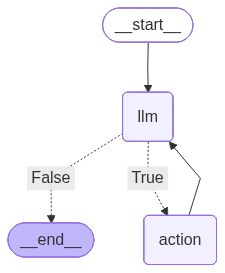

In [10]:
tool = TavilySearchResults(max_results=4)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)
abot = Agent(model, [tool], system=prompt)  
# mermaid_code = abot.graph.get_graph().draw_mermaid()
# print(mermaid_code)

from IPython.display import Image, display

try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Error al tratar generar el PNG de Mermaid: {e}")
    print("\nVerifique que la versión de LangGraph posee el método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obtener la string y visualizarla externamente.")

In [11]:
messages = [HumanMessage(content="A como quedo el dolar hoy?")]

print("Iniciando la interacción con el agente:")
final_result_state = None

#Asi lo vemos paso a paso
# for s in abot.graph.stream({"messages": messages}):
#     print("\nEstado actual del agente:")
#     print(s)
#     print("---")
#     final_result_state = s

# print(f"\nResultado Final:")
# if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
#     print(final_result_state['llm']['messages'][-1].content)
# else:
#     print("Ningún resultado final o resultado inesperado.")


# Asi lo vemos de una vez
resultado = abot.graph.invoke({
    "messages": messages
})

print(resultado["messages"][-1].content)


Iniciando la interacción con el agente:
Llamando a Gemini desde call_gemini...
Mensajes recibidos en call_gemini: [HumanMessage(content='A como quedo el dolar hoy?', additional_kwargs={}, response_metadata={})]
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'precio del dólar hoy 14/07/2026'}, 'id': '4da11a95-4b4c-4bb5-a285-f0572dfb437a', 'type': 'tool_call'}
Volviendo al modelo!
Llamando a Gemini desde call_gemini...
Mensajes recibidos en call_gemini: [HumanMessage(content='A como quedo el dolar hoy?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "precio del d\\u00f3lar hoy 14/07/2026"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f634b-f931-7912-963e-c597ede77a9a-0', tool_calls=[{'name': 'tavily_search_results_json', '

In [12]:
print("\n--- Agente de Búsqueda Interactivo ---")
print("Digite su pregunta o 'salir' para finalizar la conversación.")

while True:
    user_input = input("\nUsted: ")
    if user_input.lower() == "salir":
        print("Agente: Finalizando la conversación. Hasta luego!")
        break

    messages = [HumanMessage(content=user_input)]
    
    print("Agente: Pensando y buscando...")
    final_result_state = None
    try:
        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")
        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages'][-1]:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("No fue posible extraer el contenido de la respuesta final del LLM.")
        else:
            print("No fue posible obtener una respuesta del agente para esta pregunta.")
            
    except Exception as e:
        print(f"Agente: Se presentó un error durante la ejecución: {e}")
        print("Intente nuevamente, o digite 'salir'.")

print("\n--- Conversación finalizada ---")


--- Agente de Búsqueda Interactivo ---
Digite su pregunta o 'salir' para finalizar la conversación.
Agente: Pensando y buscando...
Llamando a Gemini desde call_gemini...
Mensajes recibidos en call_gemini: [HumanMessage(content='Donde se filmo la pelicula megalodon 2', additional_kwargs={}, response_metadata={})]
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'donde se filmo Megalodon 2'}, 'id': '20c69ba5-fb20-4cea-965e-dc7d3f116ffc', 'type': 'tool_call'}
Volviendo al modelo!
Llamando a Gemini desde call_gemini...
Mensajes recibidos en call_gemini: [HumanMessage(content='Donde se filmo la pelicula megalodon 2', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "donde se filmo Megalodon 2"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='l